# PVE Signal Sensitivity Analysis

Does increasing the proportion of variance explained (PVE) in the data
make our agents' responses more distinguishable from the null?

For each PVE level (0.0, 0.5, 1.0) and each dataset, we pool the PVE
responses as the alt group and the existing null responses as the null
group, then run an unblocked difference-in-means permutation test.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

BASE_DIR = Path("..").resolve()
sys.path.insert(0, str(BASE_DIR / "scripts"))

from calibration_sim import unblocked_perm_pvalue

In [2]:
# Load data
pve_path = BASE_DIR / "aggregated_results" / "aggregated_pve_results.csv"
null_path = BASE_DIR / "aggregated_results" / "aggregated_results.csv"

if not pve_path.exists():
    raise FileNotFoundError(
        f"Missing {pve_path.name}. Run scripts/aggregate_pve_conclusions.py first."
    )
if not null_path.exists():
    raise FileNotFoundError(
        f"Missing {null_path.name}. Run scripts/aggregate_conclusions.py first."
    )

df_pve = pd.read_csv(pve_path, keep_default_na=False)
df_null = pd.read_csv(null_path, keep_default_na=False)

# Keep only null-distribution rows from the main results
df_null = df_null[df_null["distribution"] == "null"].copy()

pve_levels = sorted(df_pve["pve_level"].unique(), key=float)
datasets = sorted(df_pve["dataset"].unique())

print(f"PVE levels: {pve_levels}")
print(f"Datasets: {datasets}")
print(f"PVE rows: {len(df_pve)}, null rows: {len(df_null)}")

PVE levels: [np.float64(0.0), np.float64(0.005), np.float64(0.01), np.float64(0.025), np.float64(0.05), np.float64(0.2), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(1.0)]
Datasets: ['affairs', 'amtl']
PVE rows: 183, null rows: 997


In [3]:
# One-sided permutation tests: PVE responses (alt) vs null responses
B = 2000
SEED = 42
rng = np.random.default_rng(SEED)

results = []
for ds in datasets:
    null_scores = df_null.loc[df_null["dataset"] == ds, "response"].values.astype(float)
    if len(null_scores) == 0:
        print(f"  {ds}: no null responses, skipping")
        continue

    for level in pve_levels:
        alt_scores = df_pve.loc[
            (df_pve["dataset"] == ds) & (df_pve["pve_level"] == level),
            "response",
        ].values.astype(float)

        if len(alt_scores) == 0:
            continue

        y = np.concatenate([alt_scores, null_scores])
        n_alt = len(alt_scores)

        p = unblocked_perm_pvalue(y, n_alt, B, agg=np.mean, rng=rng)

        results.append({
            "dataset": ds,
            "pve_level": float(level),
            "n_alt": n_alt,
            "n_null": len(null_scores),
            "alt_mean": alt_scores.mean(),
            "alt_var": alt_scores.var(),
            "null_mean": null_scores.mean(),
            "null_var": null_scores.var(),
            "p_value": p,
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="%.4f"))

dataset  pve_level  n_alt  n_null  alt_mean  alt_var  null_mean  null_var  p_value
affairs     0.0000      1      98   30.0000   0.0000    30.7653  363.9551   0.4163
affairs     0.5000      1      98    5.0000   0.0000    30.7653  363.9551   1.0000
affairs     1.0000      1      98    2.0000   0.0000    30.7653  363.9551   1.0000
   amtl     0.0000     25      98   18.0000  48.0000    26.6327  274.3140   0.9975
   amtl     0.0050     25      98   38.1200  52.4256    26.6327  274.3140   0.0010
   amtl     0.0100     25      98   65.7200  46.6816    26.6327  274.3140   0.0005
   amtl     0.0250     25      98   78.2800  51.2416    26.6327  274.3140   0.0005
   amtl     0.0500      5      98   86.2000   5.7600    26.6327  274.3140   0.0005
   amtl     0.2000     25      98   90.7600   3.3824    26.6327  274.3140   0.0005
   amtl     0.4000     25      98   92.4800   4.6496    26.6327  274.3140   0.0005
   amtl     0.6000     25      98   93.5200   4.2496    26.6327  274.3140   0.0005


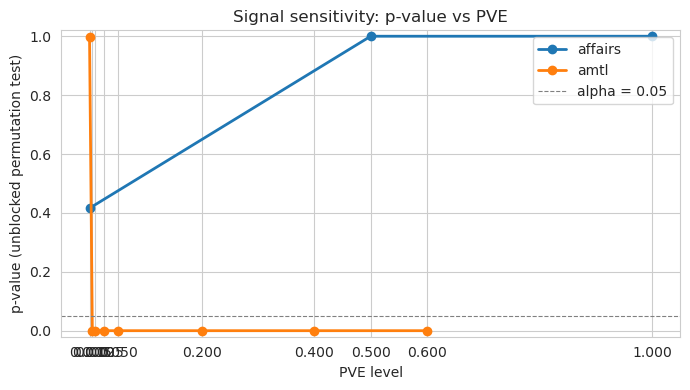

In [4]:
# Plot: p-value vs PVE level, per dataset
fig, ax = plt.subplots(figsize=(7, 4))

palette = sns.color_palette("tab10", n_colors=len(datasets))
for i, ds in enumerate(datasets):
    sub = results_df[results_df["dataset"] == ds]
    ax.plot(
        sub["pve_level"], sub["p_value"],
        marker="o", label=ds, color=palette[i], linewidth=2,
    )

ax.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="alpha = 0.05")
ax.set_xlabel("PVE level")
ax.set_ylabel("p-value (unblocked permutation test)")
ax.set_title("Signal sensitivity: p-value vs PVE")
ax.set_xticks(sorted(results_df["pve_level"].unique()))
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()